# Individual Differences Integration

Per-participant measures from across the analysis notebooks, correlated to test whether gaze-cursor lag, TTI, regression rate, and LHIPA form a coherent processing speed / search strategy dimension.

**DVs per participant:**
- Gaze-cursor lag (from `gaze_cursor_lag.ipynb`) — median ms, negative = gaze leads
- TTI to first scroll — time from page load to first scroll event
- Regression rate — fraction of trials with ≥1 backward scroll
- Mean click position — average rank of clicked result
- LHIPA — mean Low/High Index of Pupillary Activity (cognitive load, lower = more load)
- Fixation count per trial — mean across trials
- Trial duration — mean seconds

In [1]:
import csv, math, json
import numpy as np
from scipy import stats
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt

DATA = Path('../AdSERP/data')
FIX_DIR = DATA / 'fixation-data'
MOUSE_DIR = DATA / 'mouse-movement-data'
META_DIR = DATA / 'trial-metadata'
PUPIL_DIR = DATA / 'pupil-data'

RY = 1024 / 1137

print(f'Trials: {len(list(FIX_DIR.glob("*.csv")))}')
print(f'Pupil files: {len(list(PUPIL_DIR.glob("*.csv")))}')

Trials: 2776
Pupil files: 2776


In [2]:
def load_fixations(tid):
    rows = []
    with open(FIX_DIR / f'{tid}.csv') as f:
        for r in csv.DictReader(f):
            t,x,y,d = int(float(r['timestamp'])), float(r['FPOGX']), float(r['FPOGY']), float(r['FPOGD'])
            if math.isfinite(x) and math.isfinite(y) and d > 0:
                rows.append((t,x,y,d))
    return rows

def load_mouse_and_scroll(tid):
    pos_events = {'mousemove','mouseover','mouseout','click','mousedown','mouseup'}
    mouse, scrolls, clicks = [], [], []
    with open(MOUSE_DIR / f'{tid}.csv') as f:
        for r in csv.DictReader(f):
            evt = r['event'].strip()
            t = int(float(r['timestamp']))
            x, y = float(r['xpos']), float(r['ypos'])
            if not (math.isfinite(x) and math.isfinite(y)): continue
            if evt == 'scroll':
                scrolls.append((t, y))
            elif evt == 'click':
                clicks.append((t, x, y))
                mouse.append((t, x, y))
            elif evt in pos_events:
                mouse.append((t, x, y))
    return mouse, scrolls, clicks

def interp_scroll(t, scrolls):
    if not scrolls: return 0
    if t <= scrolls[0][0]: return 0
    if t >= scrolls[-1][0]: return scrolls[-1][1]
    for i in range(len(scrolls)-1):
        if scrolls[i][0] <= t < scrolls[i+1][0]:
            frac = (t - scrolls[i][0]) / (scrolls[i+1][0] - scrolls[i][0])
            return scrolls[i][1] + frac * (scrolls[i+1][1] - scrolls[i][1])
    return scrolls[-1][1]

def has_regression(scrolls):
    """Does this trial have backward scrolling?"""
    if len(scrolls) < 2: return False
    for i in range(1, len(scrolls)):
        if scrolls[i][1] < scrolls[i-1][1] - 10:  # >10px backward
            return True
    return False

def compute_lag_for_trial(fix, mouse, scrolls, step_ms=50, max_offset=2000):
    """Scroll-corrected gaze-cursor lag. Returns lag_ms or None."""
    if len(fix) < 5 or len(mouse) < 20: return None
    all_t = [f[0] for f in fix] + [m[0] for m in mouse]
    t0, t1 = min(all_t), max(all_t)
    times = np.arange(t0, t1, step_ms)
    gy = np.full(len(times), np.nan)
    for t,x,y,d in fix:
        s = interp_scroll(t, scrolls)
        mask = (times >= t) & (times < t+d)
        gy[mask] = y - s
    mt = np.array([m[0] for m in mouse], dtype=float)
    raw_my = np.array([m[2] for m in mouse], dtype=float)
    msy = np.array([(raw_my[i] - interp_scroll(int(mt[i]), scrolls)) * RY for i in range(len(mt))])
    my_interp = np.interp(times, mt, msy, left=np.nan, right=np.nan)
    offsets = np.arange(-max_offset, max_offset+1, step_ms)
    best_lag, best_r = 0, -1
    for off in offsets:
        shift = int(off / step_ms)
        g = gy[shift:] if shift >= 0 else gy[:shift if shift else len(gy)]
        m = my_interp[:len(g)] if shift >= 0 else my_interp[-shift:]
        if shift < 0:
            m = my_interp[-shift:]; g = gy[:len(m)]
        v = np.isfinite(g) & np.isfinite(m)
        if v.sum() < 20: continue
        if np.std(g[v]) < 1 or np.std(m[v]) < 1: continue
        r = np.corrcoef(g[v], m[v])[0,1]
        if np.isfinite(r) and r > best_r:
            best_r, best_lag = r, off
    return best_lag if best_r > -1 else None

print('Functions loaded')

Functions loaded


In [3]:
# ── Compute all per-trial measures ──────────────────────────────

# Load pre-computed LHIPA (dict keyed by trial_id)
lhipa_data = {}
lhipa_path = Path('lhipa_per_trial.json')
if lhipa_path.exists():
    with open(lhipa_path) as f:
        raw = json.load(f)
        for tid, entry in raw.items():
            lhipa_data[tid] = entry['lhipa']
    print(f'LHIPA loaded: {len(lhipa_data)} trials')
else:
    print('No LHIPA data — run scripts/compute_lhipa.py first')

trial_ids = sorted(p.stem for p in FIX_DIR.glob('*.csv'))
trial_measures = []

for i, tid in enumerate(trial_ids):
    if i % 500 == 0: print(f'  Processing {i}/{len(trial_ids)}...')
    try:
        fix = load_fixations(tid)
        mouse, scrolls, clicks = load_mouse_and_scroll(tid)
        if len(fix) < 3 or len(mouse) < 5: continue
        
        pid = tid.split('-')[0]
        t_start = min(fix[0][0], mouse[0][0])
        t_end = max(fix[-1][0] + fix[-1][3], mouse[-1][0])
        duration_s = (t_end - t_start) / 1000
        
        # TTI to first scroll
        tti_scroll = (scrolls[0][0] - t_start) / 1000 if scrolls else None
        
        # Orientation: time to first fixation
        orientation_ms = fix[0][0] - t_start
        
        # Regression
        regressed = has_regression(scrolls)
        
        # Gaze-cursor lag
        lag = compute_lag_for_trial(fix, mouse, scrolls)
        
        # Click position (rough: click Y / ~150px per result)
        click_pos = None
        if clicks:
            click_y = clicks[-1][2]  # last click, page-space Y
            click_pos = click_y / 150  # rough position estimate
        
        # LHIPA
        lhipa = lhipa_data.get(tid)
        
        trial_measures.append({
            'trial_id': tid,
            'participant': pid,
            'n_fixations': len(fix),
            'duration_s': duration_s,
            'tti_scroll_s': tti_scroll,
            'orientation_ms': orientation_ms,
            'regressed': regressed,
            'lag_ms': lag,
            'click_pos': click_pos,
            'lhipa': lhipa,
        })
    except Exception:
        pass

print(f'\nProcessed {len(trial_measures)} trials')

LHIPA loaded: 2721 trials
  Processing 0/2776...


  Processing 500/2776...


  Processing 1000/2776...


  Processing 1500/2776...


  Processing 2000/2776...


  Processing 2500/2776...



Processed 2772 trials


In [4]:
# ── Aggregate per participant ───────────────────────────────────

by_pid = defaultdict(list)
for m in trial_measures:
    by_pid[m['participant']].append(m)

participant_dvs = {}
for pid, trials in by_pid.items():
    lags = [t['lag_ms'] for t in trials if t['lag_ms'] is not None]
    ttis = [t['tti_scroll_s'] for t in trials if t['tti_scroll_s'] is not None]
    lhipas = [t['lhipa'] for t in trials if t['lhipa'] is not None]
    click_positions = [t['click_pos'] for t in trials if t['click_pos'] is not None]
    
    participant_dvs[pid] = {
        'n_trials': len(trials),
        'median_lag_ms': np.median(lags) if len(lags) >= 5 else None,
        'lag_sd': np.std(lags) if len(lags) >= 5 else None,
        'median_tti_s': np.median(ttis) if len(ttis) >= 5 else None,
        'regression_rate': np.mean([t['regressed'] for t in trials]),
        'mean_fixations': np.mean([t['n_fixations'] for t in trials]),
        'mean_duration_s': np.mean([t['duration_s'] for t in trials]),
        'mean_click_pos': np.mean(click_positions) if click_positions else None,
        'mean_lhipa': np.mean(lhipas) if len(lhipas) >= 5 else None,
        'mean_orientation_ms': np.median([t['orientation_ms'] for t in trials]),
    }

print(f'Participants with all measures:')
complete = {pid: dv for pid, dv in participant_dvs.items() 
            if all(dv[k] is not None for k in ['median_lag_ms','median_tti_s','mean_lhipa','mean_click_pos'])}
print(f'  {len(complete)} / {len(participant_dvs)}')

# Quick stats
for key in ['median_lag_ms', 'median_tti_s', 'regression_rate', 'mean_lhipa', 'mean_click_pos', 'mean_fixations']:
    vals = [dv[key] for dv in complete.values() if dv[key] is not None]
    print(f'  {key}: median={np.median(vals):.1f}, SD={np.std(vals):.1f}, range={np.min(vals):.1f}–{np.max(vals):.1f}')

Participants with all measures:
  46 / 47
  median_lag_ms: median=-800.0, SD=397.1, range=-1475.0–525.0
  median_tti_s: median=5.5, SD=3.5, range=0.9–17.5
  regression_rate: median=0.6, SD=0.2, range=0.0–1.0
  mean_lhipa: median=0.0, SD=0.0, range=0.0–0.1
  mean_click_pos: median=5.5, SD=0.9, range=4.0–6.9
  mean_fixations: median=88.6, SD=36.6, range=23.2–168.4


In [5]:
# ── Correlation matrix ──────────────────────────────────────────

keys = ['median_lag_ms', 'median_tti_s', 'regression_rate', 'mean_lhipa', 'mean_click_pos', 'mean_fixations', 'mean_duration_s']
labels = ['Gaze-cursor\nlag (ms)', 'TTI to\nscroll (s)', 'Regression\nrate', 'LHIPA\n(cog load)', 'Click\nposition', 'Fixation\ncount', 'Duration\n(s)']

# Build matrix from complete participants
pids = sorted(complete.keys())
matrix = np.array([[complete[pid][k] for k in keys] for pid in pids])

n = len(keys)
rho_matrix = np.zeros((n, n))
p_matrix = np.ones((n, n))

print(f'Spearman correlations (n={len(pids)} participants):\n')
print(f'{"":>20s}', end='')
for l in labels:
    print(f'{l.split(chr(10))[0]:>12s}', end='')
print()

for i in range(n):
    print(f'{labels[i].split(chr(10))[0]:>20s}', end='')
    for j in range(n):
        valid = np.isfinite(matrix[:, i]) & np.isfinite(matrix[:, j])
        if valid.sum() >= 10:
            rho, p = stats.spearmanr(matrix[valid, i], matrix[valid, j])
            rho_matrix[i, j] = rho
            p_matrix[i, j] = p
            sig = '*' if p < 0.05 else ' '
            print(f'{rho:>+11.2f}{sig}', end='')
        else:
            print(f'{"—":>12s}', end='')
    print()

print(f'\n* p < 0.05')

Spearman correlations (n=46 participants):

                     Gaze-cursor      TTI to  Regression       LHIPA       Click    Fixation    Duration
         Gaze-cursor      +1.00*      -0.17       +0.25       -0.06       +0.09       +0.04       +0.02 
              TTI to      -0.17       +1.00*      +0.13       -0.67*      +0.06       +0.72*      +0.77*
          Regression      +0.25       +0.13       +1.00*      -0.57*      +0.10       +0.63*      +0.60*
               LHIPA      -0.06       -0.67*      -0.57*      +1.00*      -0.16       -0.89*      -0.94*
               Click      +0.09       +0.06       +0.10       -0.16       +1.00*      +0.18       +0.15 
            Fixation      +0.04       +0.72*      +0.63*      -0.89*      +0.18       +1.00*      +0.94*
            Duration      +0.02       +0.77*      +0.60*      -0.94*      +0.15       +0.94*      +1.00*

* p < 0.05


In [6]:
# ── Key hypothesis tests ────────────────────────────────────────

def report_corr(label, x_key, y_key):
    x = np.array([complete[pid][x_key] for pid in pids])
    y = np.array([complete[pid][y_key] for pid in pids])
    valid = np.isfinite(x) & np.isfinite(y)
    rho, p = stats.spearmanr(x[valid], y[valid])
    print(f'{label}: ρ = {rho:+.3f}, p = {p:.4f}, n = {valid.sum()}')
    return x[valid], y[valid], rho, p

print('=== Key hypotheses ===\n')

print('H1: Gaze-cursor lag correlates with TTI (both measure processing speed)')
x1, y1, r1, p1 = report_corr('  Lag × TTI', 'median_lag_ms', 'median_tti_s')

print('\nH2: Gaze-cursor lag correlates with regression rate (strategy dimension)')
x2, y2, r2, p2 = report_corr('  Lag × Regression rate', 'median_lag_ms', 'regression_rate')

print('\nH3: Gaze-cursor lag correlates with LHIPA (cognitive load)')
x3, y3, r3, p3 = report_corr('  Lag × LHIPA', 'median_lag_ms', 'mean_lhipa')

print('\nH4: Regression rate correlates with LHIPA (replication of our earlier finding)')
x4, y4, r4, p4 = report_corr('  Regression rate × LHIPA', 'regression_rate', 'mean_lhipa')

print('\nH5: TTI correlates with regression rate')
x5, y5, r5, p5 = report_corr('  TTI × Regression rate', 'median_tti_s', 'regression_rate')

print('\nH6: Click position correlates with LHIPA (deeper foraging = more load)')
x6, y6, r6, p6 = report_corr('  Click position × LHIPA', 'mean_click_pos', 'mean_lhipa')

=== Key hypotheses ===

H1: Gaze-cursor lag correlates with TTI (both measure processing speed)
  Lag × TTI: ρ = -0.171, p = 0.2560, n = 46

H2: Gaze-cursor lag correlates with regression rate (strategy dimension)
  Lag × Regression rate: ρ = +0.246, p = 0.0995, n = 46

H3: Gaze-cursor lag correlates with LHIPA (cognitive load)
  Lag × LHIPA: ρ = -0.065, p = 0.6694, n = 46

H4: Regression rate correlates with LHIPA (replication of our earlier finding)
  Regression rate × LHIPA: ρ = -0.574, p = 0.0000, n = 46

H5: TTI correlates with regression rate
  TTI × Regression rate: ρ = +0.131, p = 0.3852, n = 46

H6: Click position correlates with LHIPA (deeper foraging = more load)
  Click position × LHIPA: ρ = -0.161, p = 0.2850, n = 46


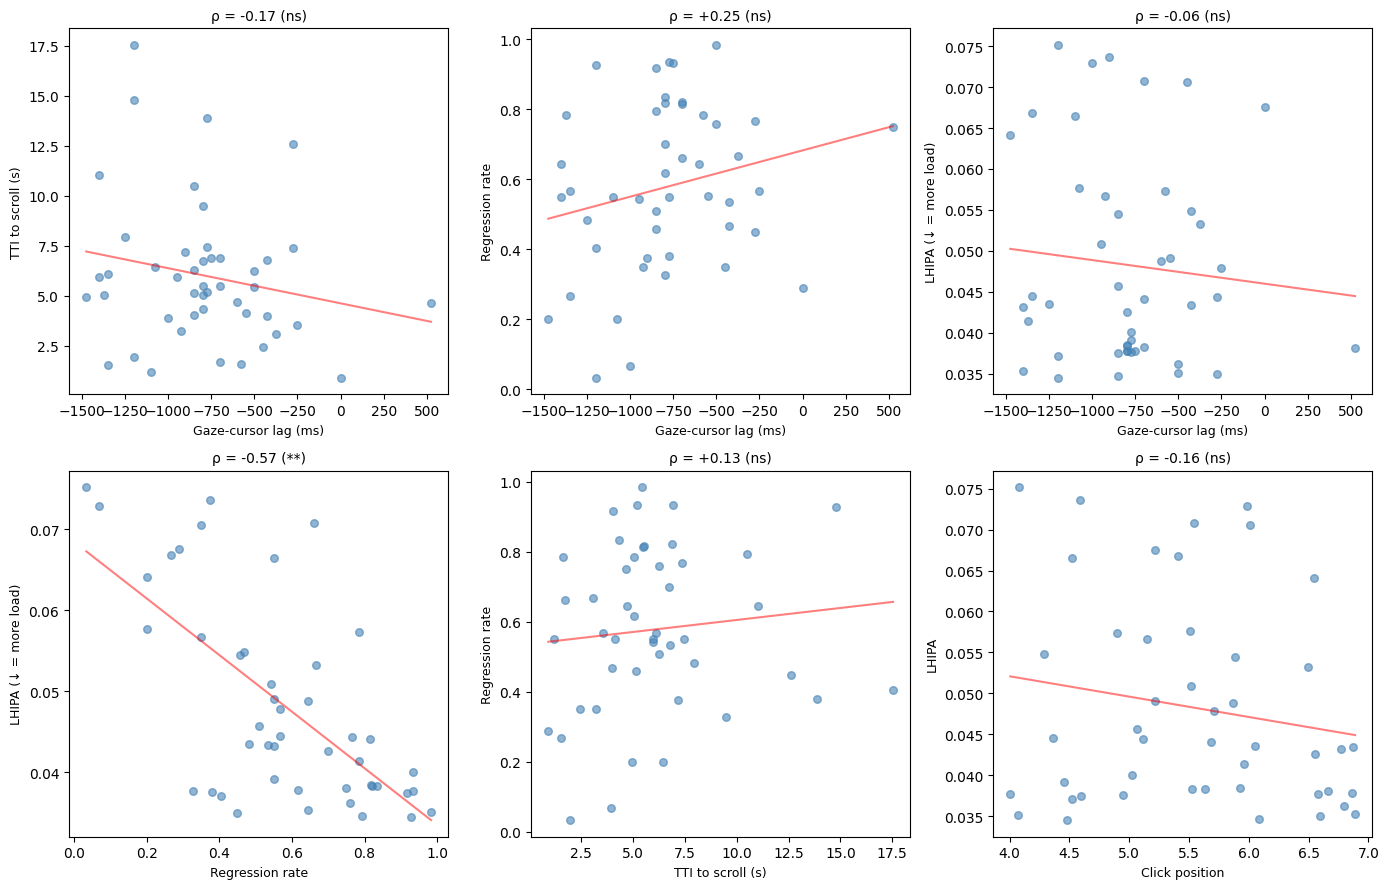

Saved: plot_individual_differences.png


In [7]:
# ── Scatter plots for significant correlations ──────────────────

pairs = [
    ('median_lag_ms', 'median_tti_s', 'Gaze-cursor lag (ms)', 'TTI to scroll (s)', r1, p1),
    ('median_lag_ms', 'regression_rate', 'Gaze-cursor lag (ms)', 'Regression rate', r2, p2),
    ('median_lag_ms', 'mean_lhipa', 'Gaze-cursor lag (ms)', 'LHIPA (↓ = more load)', r3, p3),
    ('regression_rate', 'mean_lhipa', 'Regression rate', 'LHIPA (↓ = more load)', r4, p4),
    ('median_tti_s', 'regression_rate', 'TTI to scroll (s)', 'Regression rate', r5, p5),
    ('mean_click_pos', 'mean_lhipa', 'Click position', 'LHIPA', r6, p6),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, (xk, yk, xl, yl, rho, p) in enumerate(pairs):
    ax = axes[i]
    x = np.array([complete[pid][xk] for pid in pids])
    y = np.array([complete[pid][yk] for pid in pids])
    valid = np.isfinite(x) & np.isfinite(y)
    ax.scatter(x[valid], y[valid], alpha=0.6, s=30, color='steelblue')
    
    # Trend line
    if valid.sum() >= 5:
        z = np.polyfit(x[valid], y[valid], 1)
        xline = np.linspace(np.min(x[valid]), np.max(x[valid]), 50)
        ax.plot(xline, np.polyval(z, xline), 'r-', alpha=0.5)
    
    sig = '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.set_xlabel(xl, fontsize=9)
    ax.set_ylabel(yl, fontsize=9)
    ax.set_title(f'ρ = {rho:+.2f} ({sig})', fontsize=10)

plt.tight_layout()
plt.savefig('plots-v1/plot_individual_differences.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_individual_differences.png')

Split-half reliability of gaze-cursor lag:
  r = 0.611, p = 0.0000, n = 46 participants
  Spearman-Brown corrected: 0.759
  (> 0.7 = acceptable reliability as individual difference measure)


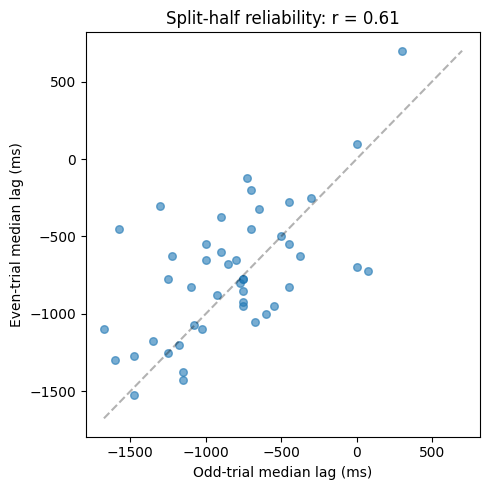

In [8]:
# ── Within-participant stability (ICC proxy) ───────────────────
# For gaze-cursor lag: is it a stable trait or state-dependent?

# Split each participant's trials into odd/even halves
odd_medians, even_medians = [], []
for pid in pids:
    trials_with_lag = [t for t in by_pid[pid] if t['lag_ms'] is not None]
    if len(trials_with_lag) < 10: continue
    odd = [t['lag_ms'] for i, t in enumerate(trials_with_lag) if i % 2 == 1]
    even = [t['lag_ms'] for i, t in enumerate(trials_with_lag) if i % 2 == 0]
    odd_medians.append(np.median(odd))
    even_medians.append(np.median(even))

odd_medians = np.array(odd_medians)
even_medians = np.array(even_medians)

if len(odd_medians) >= 10:
    split_half_r, split_half_p = stats.pearsonr(odd_medians, even_medians)
    print(f'Split-half reliability of gaze-cursor lag:')
    print(f'  r = {split_half_r:.3f}, p = {split_half_p:.4f}, n = {len(odd_medians)} participants')
    print(f'  Spearman-Brown corrected: {2*split_half_r/(1+split_half_r):.3f}')
    print(f'  (> 0.7 = acceptable reliability as individual difference measure)')
    
    plt.figure(figsize=(5, 5))
    plt.scatter(odd_medians, even_medians, alpha=0.6, s=30)
    lims = [min(odd_medians.min(), even_medians.min()), max(odd_medians.max(), even_medians.max())]
    plt.plot(lims, lims, 'k--', alpha=0.3)
    plt.xlabel('Odd-trial median lag (ms)')
    plt.ylabel('Even-trial median lag (ms)')
    plt.title(f'Split-half reliability: r = {split_half_r:.2f}')
    plt.tight_layout()
    plt.savefig('plots-v1/plot_lag_split_half.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'Not enough participants with ≥10 trials for split-half: {len(odd_medians)}')

## Summary

If the key correlations are significant, it suggests a coherent individual-differences dimension:

**Processing speed / deliberation trait:**
- Faster gaze-cursor lag → faster TTI → lower regression rate → shallower click → lower cognitive load
- = "satisficer" profile

**Slower / more deliberate:**
- Longer lag → slower TTI → more regressions → deeper (or higher) click → more cognitive load
- = "optimizer" profile

The gaze-cursor lag would be a third independent measure of this dimension, alongside TTI and regression rate — converging evidence from motor, temporal, and behavioral signals.